# Basic tracking of the LCLS cu_hxr design model with a beam dump file

This is similar to the `lcls_beam_tracking` notebook, but with fixed markers to dump the beam at.

Note that overlays that change lengths need special handling.

In [1]:
from pytao import Tao
from pmd_beamphysics import ParticleGroup
from scipy.constants import c
import matplotlib.pyplot as plt
import h5py
import numpy as np
import pandas as pd
import os
%config InlineBackend.figure_format = 'retina'

from pytao.misc.markers import make_markers

# Setup

Slice lattice with markers

In [2]:
BEAMPATH = 'cu_hxr'
track_start = 'OTR2'
track_end = 'BEGUNDH'
N_PARTICLE = 10_000
TEMPDIR = 'temp'
ds_dump = 1 # m

tao = Tao(f'-init $LCLS_LATTICE/bmad/models/{BEAMPATH}/tao.init -slice {track_start}:{track_end} -noplot')

if not os.path.exists(TEMPDIR):
    os.mkdir(TEMPDIR)
tao.cmd(f'write bmad {TEMPDIR}/lat.bmad')

s0 = tao.ele_head(track_start)['s']
s1 = tao.ele_head(track_end)['s']
slist = np.arange(s0, s1, ds_dump)
make_markers(slist, filename=f'{TEMPDIR}/markers.bmad')


lat2 = f"""
call, file = lat.bmad
! Special commands to avoid overlay and taylor slicing problems
O_BC1_OFFSET[is_on] = F
O_BC2_OFFSET[is_on] = F
O_BC1[is_on] = F
O_BC2[is_on] = F
PS*[is_on] = F
expand_lattice
call, file = markers.bmad
"""
lat2file = f'{TEMPDIR}/lat2.bmad'
with open(lat2file, 'w') as f:
    f.write(lat2)

tao = Tao(f'-init $LCLS_LATTICE/bmad/models/{BEAMPATH}/tao.init -slice {track_start}:{track_end} -lat {lat2file} -noplot')

In [3]:
# Some checks
assert tao.ele_head(track_start)['s']  == s0
assert tao.ele_head(track_end)['s']  == s1

# Track beam 

In [4]:
tao.cmd('set beam dump_file = beam_dump.h5')
tao.cmd('set beam dump_at = marker::M_*')
tao.cmd(f'set beam track_start = {track_start}')
tao.cmd(f'set beam track_end = {track_end}')

[]

In [5]:
tao.cmd(f'set beam_init n_particle = {N_PARTICLE}')

[]

In [6]:
%%time
tao.cmd('set global track_type = beam;set global track_type = single')

CPU times: user 43.9 s, sys: 1.79 s, total: 45.7 s
Wall time: 15.4 s


['',
 'Tao: set global track_type = beam',
 '',
 'Tao: set global track_type = single']

# Examine the Beam Dump file

In [7]:
h5 = h5py.File('beam_dump.h5')

In [8]:
steps = list(h5['data'])
ix = 0
steps[ix]

'00001'

In [9]:
ix = 0
list(h5['data'][steps[0]]['particles/'])

['branchIndex',
 'elementIndex',
 'locationInElement',
 'momentum',
 'particleStatus',
 'position',
 'sPosition',
 'spin',
 'time',
 'timeOffset',
 'totalMomentum',
 'totalMomentumOffset',
 'weight']

In [10]:
h5['data'][steps[0]]['particles/elementIndex'].attrs['value'][0]

np.int32(5)

In [11]:
tao.ele_head(3)['name']

'BPM10'

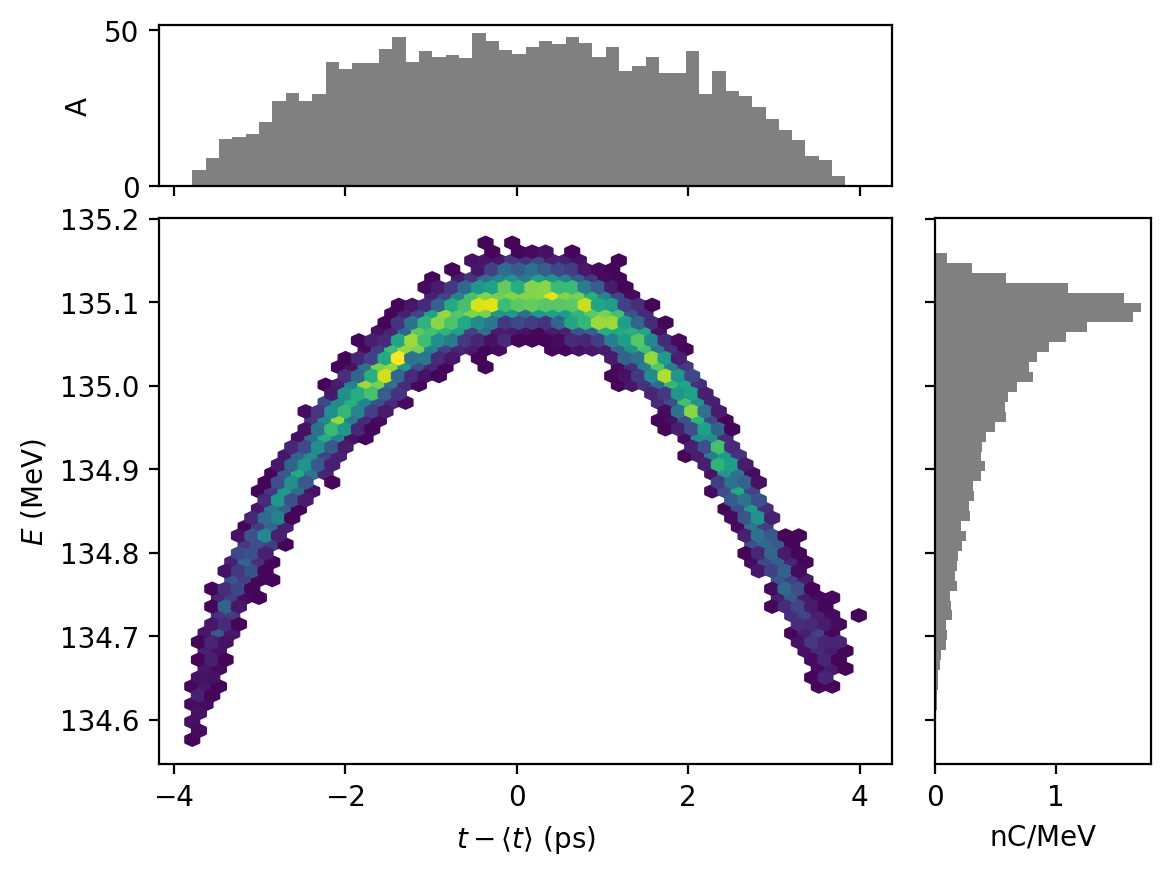

In [12]:
P = ParticleGroup(h5=h5['data'][steps[0]]['particles/'] )
P.plot('delta_t', 'energy')

In [13]:
def extract_info(paritclegroup):
    """
    Normal ParticleGroup data
    """
    keys = ['norm_emit_x', 'norm_emit_y', 'sigma_t', 'mean_energy']
    data = {}
    for key in keys:
        data[key] = paritclegroup[key]
    return data
extract_info(P)

{'norm_emit_x': np.float64(4.856475451843102e-07),
 'norm_emit_y': np.float64(5.014660103367774e-07),
 'sigma_t': np.float64(1.7830366381135214e-12),
 'mean_energy': np.float64(135001801.54913446)}

In [14]:
P['sigma_t']

np.float64(1.7830366381135214e-12)

# Loop over all steps

In [15]:
%%time
data = []
for step in steps:
    P = ParticleGroup(h5=h5['data'][step]['particles/'] )
    n_tot = len(P)
    P = P[P.status == 1] # Only 
    n_alive = len(P)
    info = extract_info(P)

    # add extra info
    ix_ele = h5['data'][step]['particles/elementIndex'].attrs['value'][0]
    s = h5['data'][step]['particles/sPosition'].attrs['value'][0]
    info['ix_ele'] = ix_ele
    info['s'] = s
    info['n_lost'] = n_tot - n_alive
    info['n_alive'] = n_alive
    data.append(info)

df = pd.DataFrame(data)
df

CPU times: user 5.83 s, sys: 445 ms, total: 6.27 s
Wall time: 6.32 s


,norm_emit_x,norm_emit_y,sigma_t,mean_energy,ix_ele,s,n_lost,n_alive
0,4.856475e-07,5.014660e-07,1.783037e-12,1.350018e+08,5,14.637671,0,10000
1,4.857136e-07,5.016221e-07,1.783038e-12,1.350018e+08,7,15.637671,0,10000
2,4.855062e-07,5.018937e-07,1.783043e-12,1.350018e+08,20,16.637671,0,10000
3,1.680540e-06,5.021748e-07,1.783584e-12,1.350018e+08,33,17.637671,0,10000
4,1.677363e-06,5.022151e-07,1.783593e-12,1.350018e+08,46,18.637671,0,10000
...,...,...,...,...,...,...,...,...
1529,4.842954e-07,5.083199e-07,2.444965e-14,7.979857e+09,4997,1543.482058,0,10000
1530,4.842839e-07,5.083194e-07,2.444964e-14,7.979857e+09,4999,1544.482058,0,10000
1531,4.842724e-07,5.083189e-07,2.444963e-14,7.979857e+09,5007,1545.482058,0,10000
1532,4.842610e-07,5.083184e-07,2.444962e-14,7.979857e+09,5011,1546.482058,0,10000


# Plot

<Axes: xlabel='s'>

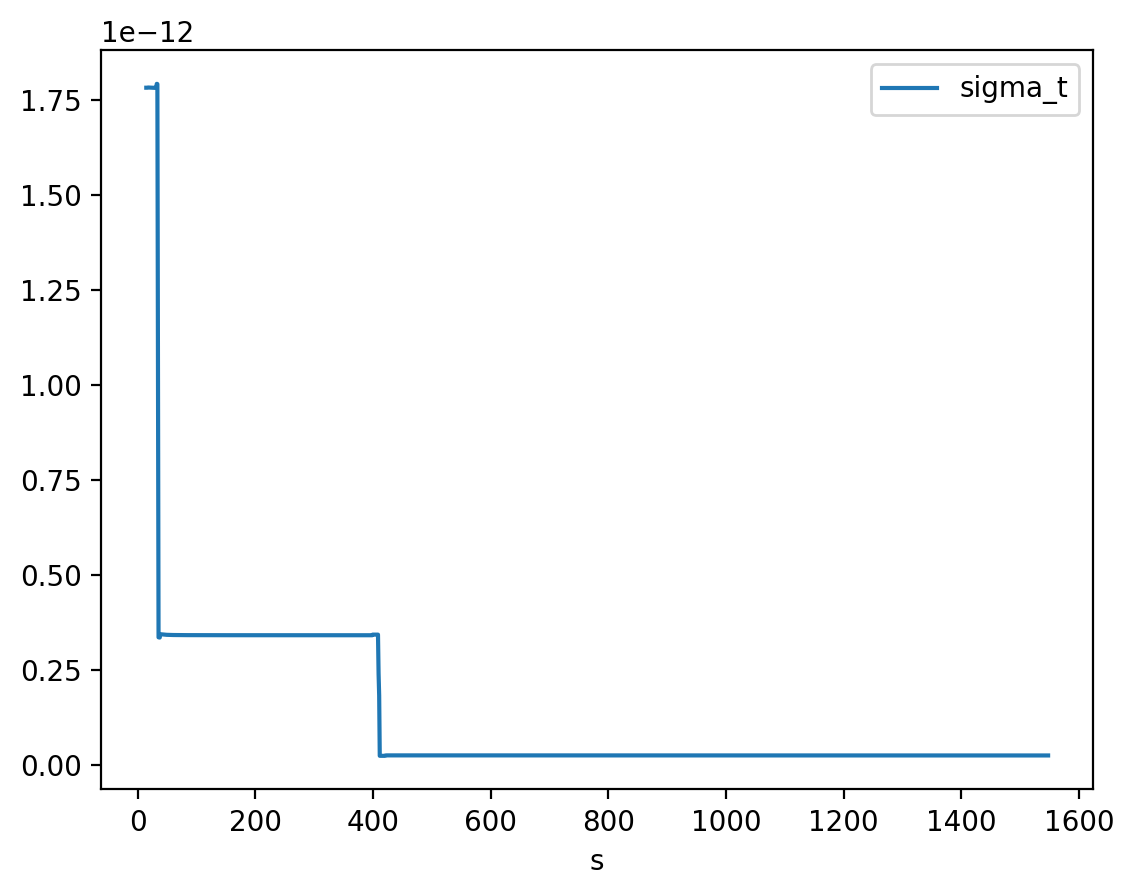

In [16]:
df.plot('s', 'sigma_t')

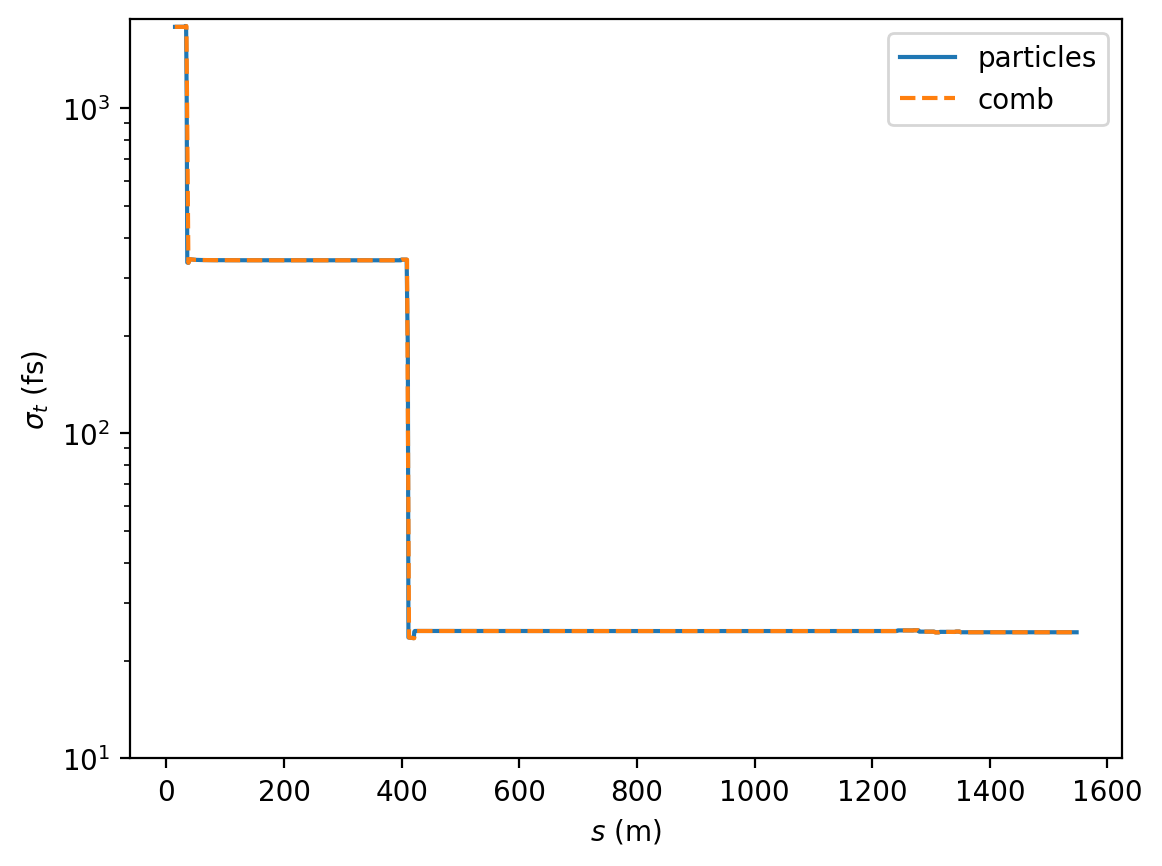

In [17]:
s = df['s']
sigma_t =  df['sigma_t']

fig, ax = plt.subplots()
ax.plot(s,sigma_t*1e15, label='particles')

comb_s = tao.bunch_comb('s')
comb_sigma_t =  tao.bunch_comb('z.sigma')/c
ax.plot(comb_s,comb_sigma_t*1e15, '--', label='comb')


ax.set_ylabel(r'$\sigma_t$ (fs)')
ax.set_xlabel(r'$s$ (m)')
ax.set_ylim(10, None)
ax.set_yscale('log')
plt.legend()
#ax2 = ax.twinx()
#ax2.plot(s, sigma_z, color='red')
#ax2.set_yscale('log')

In [18]:
from ipywidgets import interact

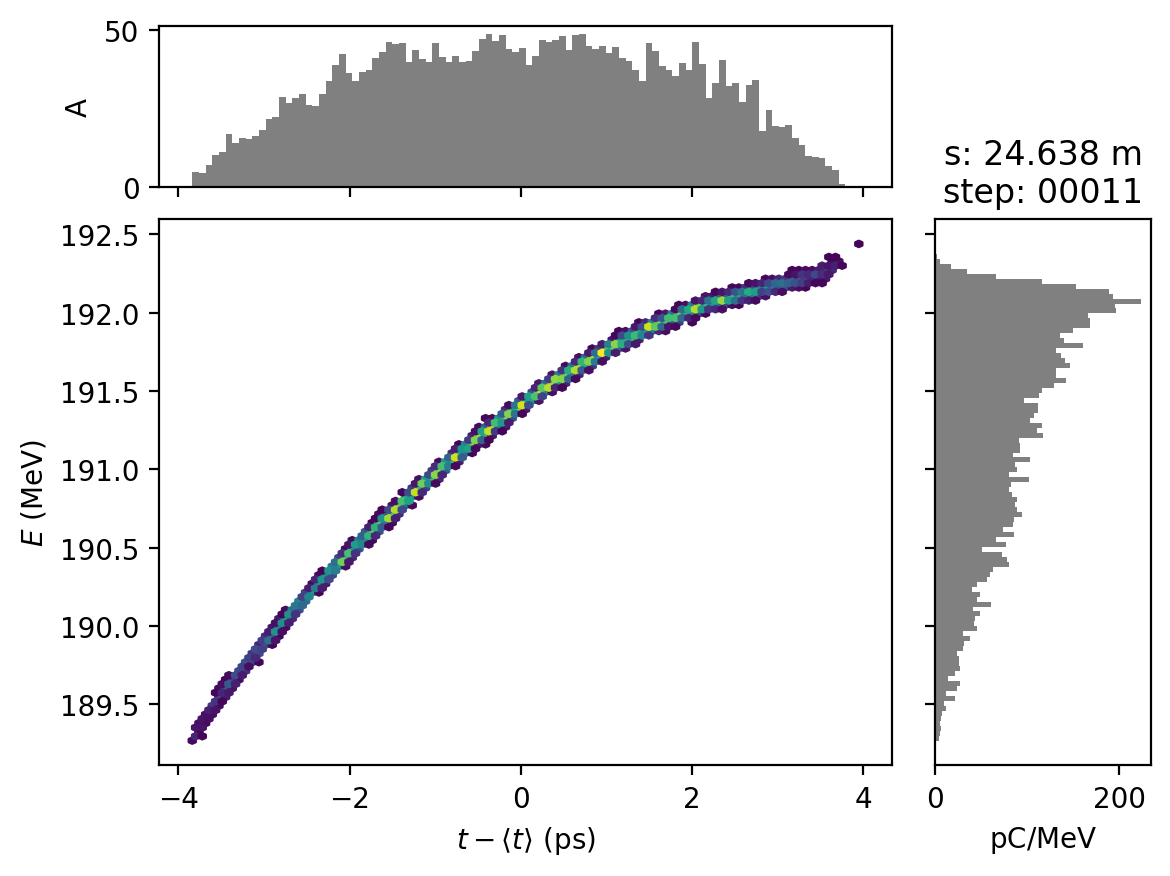

In [19]:
def plot1(ix):

    framesdir=None
    step = steps[ix]
    #if ix % 10 == 0:
    #    print(step)
    P = ParticleGroup(h5=h5['data'][step]['particles/'] )
    P = P[P.status == 1] # Only keep live particles
    fig = P.plot('delta_t', 'energy', bins=100, return_figure = True)

    # Add some info to the plot
    s = h5['data'][step]['particles/sPosition'].attrs['value'][0]
    ax = fig.axes[2]
    ax.set_title(f's: {s:.3f} m\nstep: {step}')

def save_plot1(ix, framesdir):
    plot1(ix)
    step = steps[ix]
    fname = f'frame_{step}.png'
    fout = os.path.join(framesdir, fname)
    plt.savefig(fout, dpi=150)
    plt.close()

    


#save_plot1(2, framesdir='frames')

#interact(plot1, ix=(0,len(steps)-1))

plot1(10)

# Make frames for a movie

In [20]:
FRAMESDIR = 'frames'
if not os.path.exists(FRAMESDIR):
    os.mkdir(FRAMESDIR)

In [21]:
# Test
save_plot1(2, framesdir='frames')

In [22]:
# Clear out old frames
!rm frames/*

In [23]:
%%time
for ix in range(len(steps)):
    if ix % 100 == 0:
        print(f'{ix} / {len(steps)}')
    save_plot1(ix, framesdir=FRAMESDIR)

0 / 1534
100 / 1534
200 / 1534
300 / 1534
400 / 1534
500 / 1534
600 / 1534
700 / 1534
800 / 1534
900 / 1534
1000 / 1534
1100 / 1534
1200 / 1534
1300 / 1534
1400 / 1534
1500 / 1534
CPU times: user 4min 25s, sys: 5.46 s, total: 4min 30s
Wall time: 4min 32s


In [24]:
#os.mkdir('frames')
WORKDIR = os.path.abspath(FRAMESDIR)

assert os.path.exists(WORKDIR)

In [25]:
# Make movie
!ffmpeg -y -framerate 60 -i {WORKDIR}/frame_%05d.png -c:v libx264 -pix_fmt yuv420p particle_movie.mp4

ffmpeg version 7.0.1 Copyright (c) 2000-2024 the FFmpeg developers
  built with clang version 16.0.6
  configuration: --prefix=/Users/runner/miniforge3/conda-bld/ffmpeg_1719926074525/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_pl --cc=arm64-apple-darwin20.0.0-clang --cxx=arm64-apple-darwin20.0.0-clang++ --nm=arm64-apple-darwin20.0.0-nm --ar=arm64-apple-darwin20.0.0-ar --disable-doc --disable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --enable-cross-compile --arch=arm64 --target-os=darwin --cross-prefix=arm64-apple-darwin20.0.0- --host-cc=/Users/runner/miniforge3/conda-bld/ffmpeg_1719926074525/_build_env/bin/x86_64-apple-darwin13.4.0-clang --enable-neon --enable-gnutls --enable-libmp3lame --enable-libvpx --enable-libass -